In [23]:
import os
print(os.listdir())

['.ipynb_checkpoints', '01_data_load_and_explore.ipynb', '02_explorar_visualizar_dados.ipynb', 'archive']


In [24]:
import pandas as pd

movies = pd.read_csv('archive/movies.csv')
credits = pd.read_csv('archive/credits.csv')

df = movies.merge(credits, left_on='id', right_on='movie_id')
df.head()


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,spoken_languages,status,tagline,title_x,vote_average,vote_count,movie_id,title_y,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração estética
plt.style.use('seaborn-v0_8')
sns.set_palette('pastel')


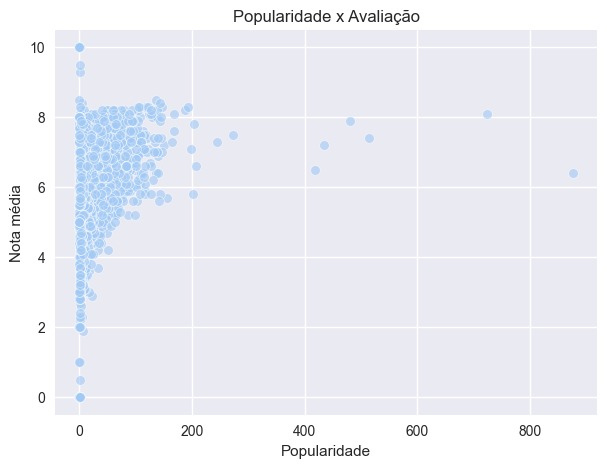

In [26]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='popularity', y='vote_average', alpha=0.6)
plt.title('Popularidade x Avaliação')
plt.xlabel('Popularidade')
plt.ylabel('Nota média')
plt.show()


In [35]:
from collections import Counter
import pandas as pd

todos_generos = sum(df['genres_list'], [])
contagem = Counter(todos_generos)
top_generos = pd.DataFrame(contagem.most_common(10), columns=['Gênero', 'Quantidade'])
top_generos


,Gênero,Quantidade
0,Drama,2297
1,Comedy,1722
2,Thriller,1274
3,Action,1154
4,Romance,894
5,Adventure,790
6,Crime,696
7,Science Fiction,535
8,Horror,519
9,Family,513


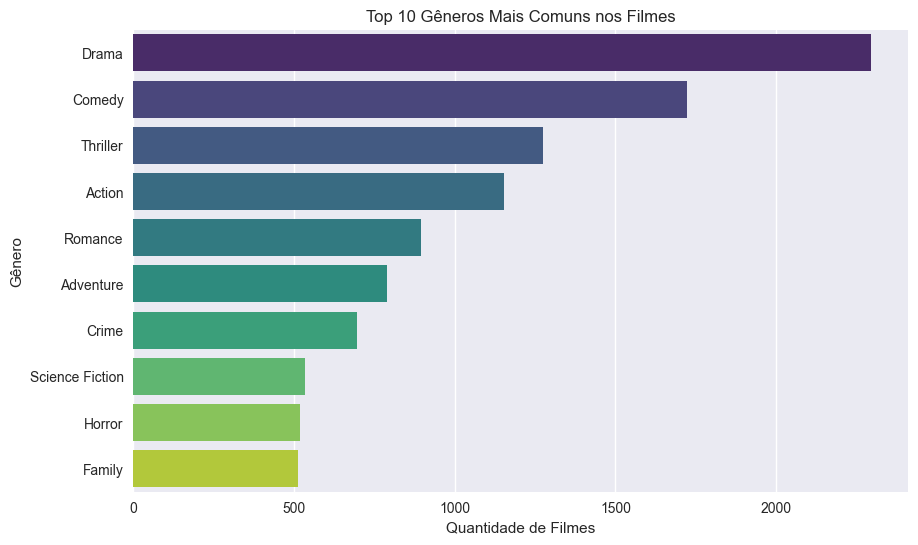

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(data=top_generos, x='Quantidade', y='Gênero', hue='Gênero', palette='viridis', legend=False)
plt.title('Top 10 Gêneros Mais Comuns nos Filmes')
plt.xlabel('Quantidade de Filmes')
plt.ylabel('Gênero')
plt.show()


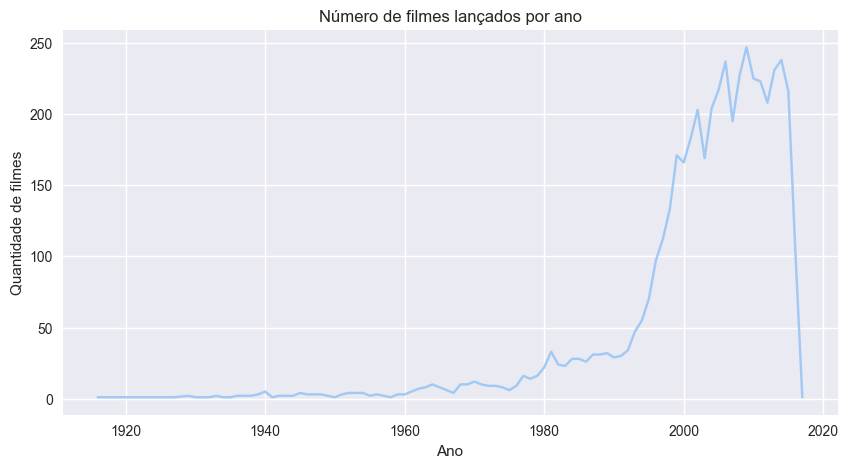

In [39]:
df['release_year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year

filmes_por_ano = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.plot(filmes_por_ano.index, filmes_por_ano.values)
plt.title('Número de filmes lançados por ano')
plt.xlabel('Ano')
plt.ylabel('Quantidade de filmes')
plt.show()


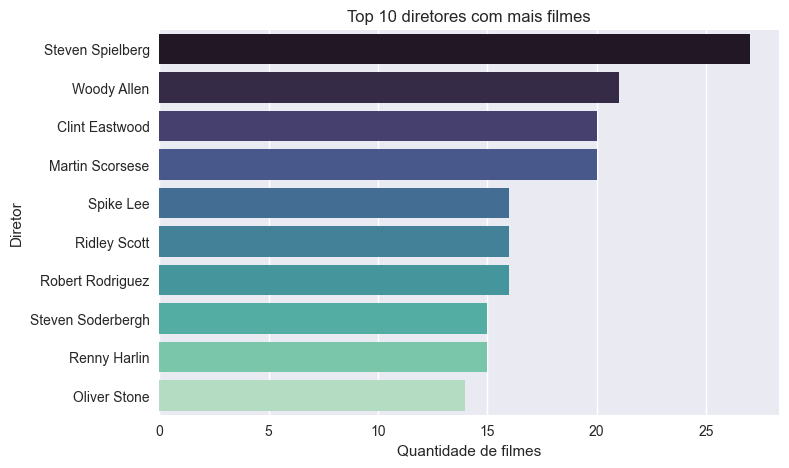

In [41]:
import ast

def get_director(crew_data):
    try:
        crew_list = ast.literal_eval(crew_data)
        for person in crew_list:
            if person.get('job') == 'Director':
                return person.get('name')
    except:
        return None

df['director'] = df['crew'].apply(get_director)

diretores_top = df['director'].value_counts().head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=diretores_top.values, y=diretores_top.index, hue=diretores_top.index, palette='mako', legend=False)
plt.title('Top 10 diretores com mais filmes')
plt.xlabel('Quantidade de filmes')
plt.ylabel('Diretor')
plt.show()
